<a href="https://colab.research.google.com/github/4GTTN/Colab/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100

import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dropout, BatchNormalization, ReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adadelta
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import math
import os
from google.colab import drive

%matplotlib inline

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [ ]:
def train_and_output(model):
  model.compile(loss='categorical_crossentropy', optimizer=Adadelta(), metrics=['accuracy'])
  history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test), verbose=1)
  plt.plot(history.history['accuracy'],
          label='Доля верных ответов на обучающем наборе')
  plt.plot(history.history['val_accuracy'],
          label='Доля верных ответов на проверочном наборе')
  plt.xlabel('Эпоха обучения')
  plt.ylabel('Доля верных ответов')
  plt.legend()
  plt.show()
  print('='*30)
  print('Train result')
  scores = model.evaluate(x_test, y_test, verbose=1)

  print(f'\n{scores}')
  print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

# Light

## Эксперименты с сетью

### Изменение количества карт признаков
Слой Conv2D, классический скрытый на 128 нейронов, выходной слой

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 130ms/step - accuracy: 0.2210 - loss: 2.2641 - val_accuracy: 0.4033 - val_loss: 2.0805
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.5857 - loss: 1.9509 - val_accuracy: 0.7224 - val_loss: 1.8014
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - accuracy: 0.7436 - loss: 1.6894 - val_accuracy: 0.7778 - val_loss: 1.5479
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 125ms/step - accuracy: 0.7795 - loss: 1.4539 - val_accuracy: 0.8013 - val_loss: 1.3255
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 125ms/step - accuracy: 0.8010 - loss: 1.2566 - val_accuracy: 0.8170 - val_loss: 1.1492
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.8152 - loss: 1.1016 - val_accuracy: 0.8299 - val_loss: 1.0135
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 126ms/step - accuracy: 0.8272 - loss: 0.9833 - val_accuracy: 0.8406 - val_loss: 0.9095
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.8366 - loss: 0

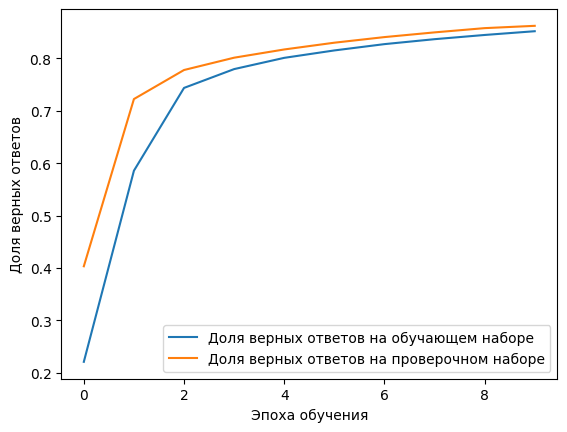

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8621 - loss: 0.7191

[0.7191212177276611, 0.8621000051498413]
Доля верных ответов на тестовых данных: 86.21%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.1605 - loss: 2.2535 - val_accuracy: 0.3431 - val_loss: 2.1228
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.5082 - loss: 2.0294 - val_accuracy: 0.6569 - val_loss: 1.9232
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.6781 - loss: 1.8386 - val_accuracy: 0.7291 - val_loss: 1.7311
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.7272 - loss: 1.6526 - val_accuracy: 0.7646 - val_loss: 1.5445
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.7580 - loss: 1.4769 - val_accuracy: 0.7884 - val_loss: 1.3751
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.7787 - loss: 1.3210 - val_accuracy: 0.8048 - val_loss: 1.2286
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s

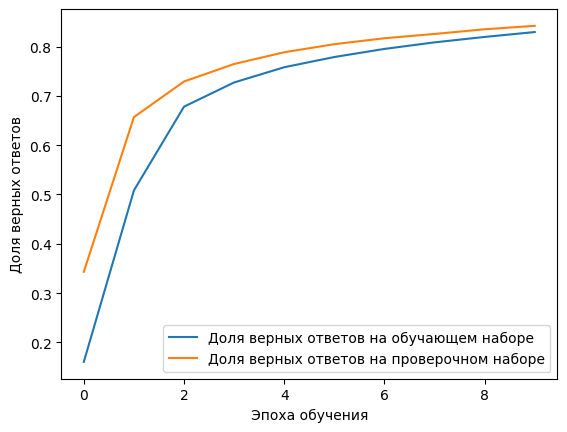

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8420 - loss: 0.8613

[0.8612692356109619, 0.8420000076293945]
Доля верных ответов на тестовых данных: 84.2%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1160 - loss: 2.3252 - val_accuracy: 0.1197 - val_loss: 2.2926
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.1548 - loss: 2.2650 - val_accuracy: 0.1960 - val_loss: 2.2351
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.2438 - loss: 2.2114 - val_accuracy: 0.2960 - val_loss: 2.1827
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.3504 - loss: 2.1612 - val_accuracy: 0.4164 - val_loss: 2.1322
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4534 - loss: 2.1118 - val_accuracy: 0.5088 - val_loss: 2.0814
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5282 - loss: 2.0613 - val_accuracy: 0.5722 - val_loss: 2.0289
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 

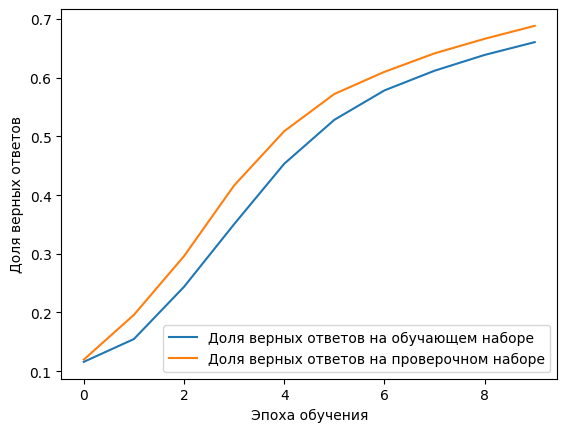

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6883 - loss: 1.7933

[1.793278694152832, 0.6883000135421753]
Доля верных ответов на тестовых данных: 68.83%


In [ ]:
models = []

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(32, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(2, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

for model in models:
  train_and_output(model)

### Изменение функций активации сверточного слоя

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 126ms/step - accuracy: 0.2903 - loss: 2.1949 - val_accuracy: 0.5155 - val_loss: 1.9355
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 117ms/step - accuracy: 0.6202 - loss: 1.7441 - val_accuracy: 0.7087 - val_loss: 1.5520
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.7397 - loss: 1.4211 - val_accuracy: 0.7775 - val_loss: 1.2766
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.7847 - loss: 1.1913 - val_accuracy: 0.8048 - val_loss: 1.0839
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.8080 - loss: 1.0307 - val_accuracy: 0.8215 - val_loss: 0.9487
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.8235 - loss: 0.9171 - val_accuracy: 0.8374 - val_loss: 0.8521
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.8347 - loss: 0.8339 - val_accuracy: 0.8461 - val_loss: 0.7804
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.8438 - loss: 0

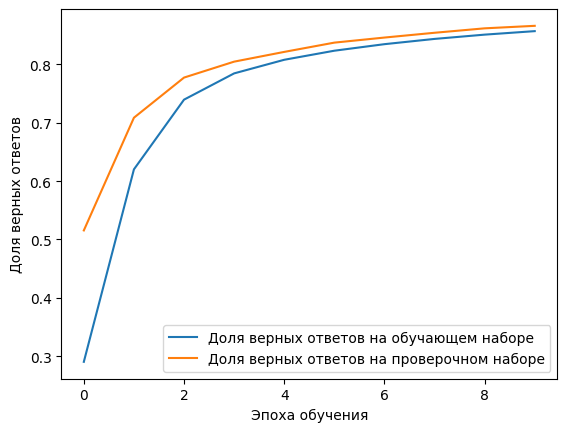

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8662 - loss: 0.6444

[0.6444032192230225, 0.8661999702453613]
Доля верных ответов на тестовых данных: 86.62%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.1127 - loss: 2.3614 - val_accuracy: 0.1435 - val_loss: 2.2462
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.2864 - loss: 2.1736 - val_accuracy: 0.4753 - val_loss: 2.1047
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 69ms/step - accuracy: 0.5803 - loss: 2.0455 - val_accuracy: 0.6512 - val_loss: 1.9788
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.6762 - loss: 1.9193 - val_accuracy: 0.7110 - val_loss: 1.8479
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.7175 - loss: 1.7866 - val_accuracy: 0.7409 - val_loss: 1.7096
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.7391 - loss: 1.6490 - val_accuracy: 0.7613 - val_loss: 1.5699
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s

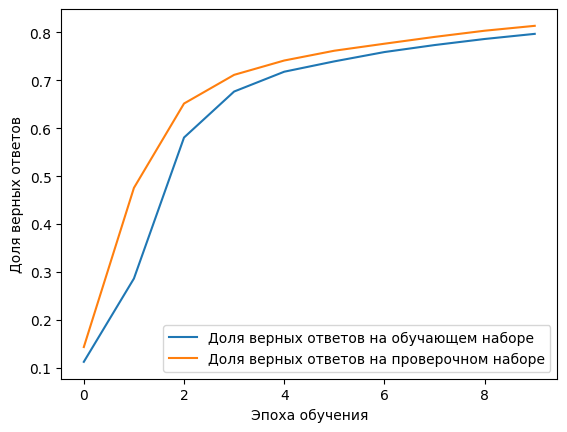

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8132 - loss: 1.1024

[1.102400541305542, 0.8131999969482422]
Доля верных ответов на тестовых данных: 81.32%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.1013 - loss: 2.4759 - val_accuracy: 0.0961 - val_loss: 2.4021
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.1249 - loss: 2.3454 - val_accuracy: 0.1809 - val_loss: 2.3068
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.2157 - loss: 2.2775 - val_accuracy: 0.2603 - val_loss: 2.2572
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.2851 - loss: 2.2401 - val_accuracy: 0.3295 - val_loss: 2.2258
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.3483 - loss: 2.2127 - val_accuracy: 0.3801 - val_loss: 2.1996
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.3890 - loss: 2.1877 - val_accuracy: 0.4255 - val_loss: 2.1743
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 

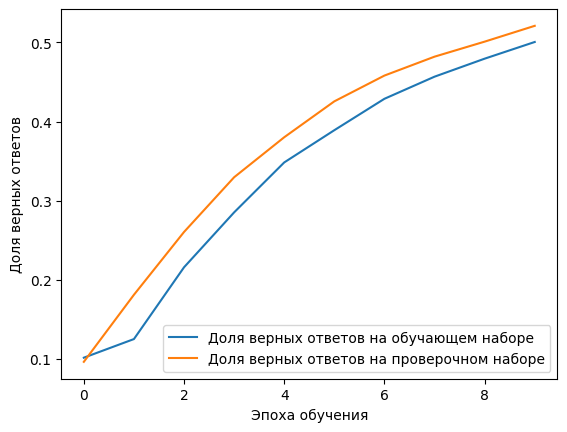

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5210 - loss: 2.0685

[2.068460464477539, 0.5210000276565552]
Доля верных ответов на тестовых данных: 52.1%


In [ ]:
models = []

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(32, (3, 3), padding='valid', activation='linear'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(2, (3, 3), padding='valid', activation='sigmoid'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

for model in models:
  train_and_output(model)

### Изменение количества сверточных слоев

2 слоя с 32 картами, 2 слоя с 16 картами, 2 слоя с 32 и 16 катрами.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 241ms/step - accuracy: 0.1433 - loss: 2.3648 - val_accuracy: 0.1877 - val_loss: 2.2379
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - accuracy: 0.3267 - loss: 2.1490 - val_accuracy: 0.5983 - val_loss: 2.0459
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 235ms/step - accuracy: 0.6737 - loss: 1.9220 - val_accuracy: 0.7363 - val_loss: 1.7595
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 240ms/step - accuracy: 0.7498 - loss: 1.5821 - val_accuracy: 0.7822 - val_loss: 1.3766
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - accuracy: 0.7883 - loss: 1.2265 - val_accuracy: 0.8146 - val_loss: 1.0650
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - accuracy: 0.8146 - loss: 0.9787 - val_accuracy: 0.8341 - val_loss: 0.8712
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 238ms/step - accuracy: 0.8340 - loss: 0.8262 - val_accuracy: 0.8499 - val_loss: 0.7506
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 235ms/step - accuracy: 0.8478 -

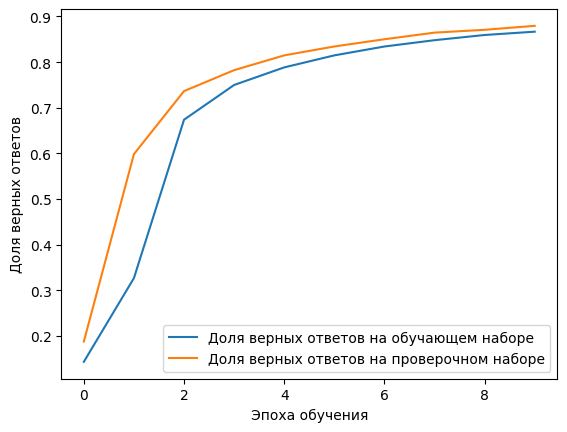

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8793 - loss: 0.5699

[0.5698927640914917, 0.8792999982833862]
Доля верных ответов на тестовых данных: 87.93%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 121ms/step - accuracy: 0.1303 - loss: 2.4981 - val_accuracy: 0.1857 - val_loss: 2.3666
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - accuracy: 0.2243 - loss: 2.2499 - val_accuracy: 0.3250 - val_loss: 2.1266
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - accuracy: 0.4791 - loss: 2.0242 - val_accuracy: 0.6562 - val_loss: 1.9028
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - accuracy: 0.7069 - loss: 1.7874 - val_accuracy: 0.7617 - val_loss: 1.6403
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 124ms/step - accuracy: 0.7646 - loss: 1.5137 - val_accuracy: 0.7959 - val_loss: 1.3562
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 125ms/step - accuracy: 0.7916 - loss: 1.2537 - val_accuracy: 0.8150 - val_loss: 1.1216
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━

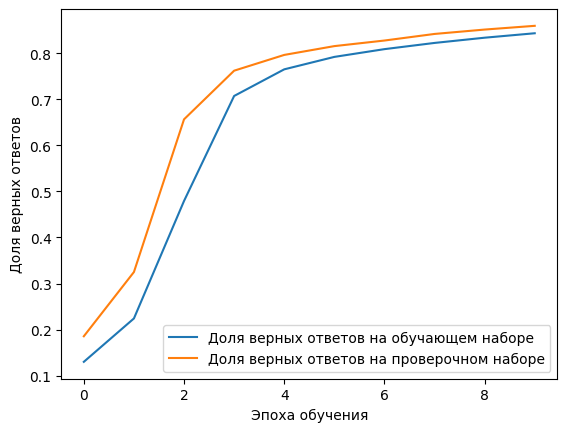

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8590 - loss: 0.7045

[0.7045196294784546, 0.859000027179718]
Доля верных ответов на тестовых данных: 85.9%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 167ms/step - accuracy: 0.1613 - loss: 2.2925 - val_accuracy: 0.2374 - val_loss: 2.1899
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - accuracy: 0.3336 - loss: 2.0764 - val_accuracy: 0.5049 - val_loss: 1.9362
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 166ms/step - accuracy: 0.6306 - loss: 1.7884 - val_accuracy: 0.7261 - val_loss: 1.6084
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - accuracy: 0.7417 - loss: 1.4544 - val_accuracy: 0.7764 - val_loss: 1.2774
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.7836 - loss: 1.1649 - val_accuracy: 0.8078 - val_loss: 1.0325
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.8088 - loss: 0.9680 - val_accuracy: 0.8300 - val_loss: 0.8757
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━

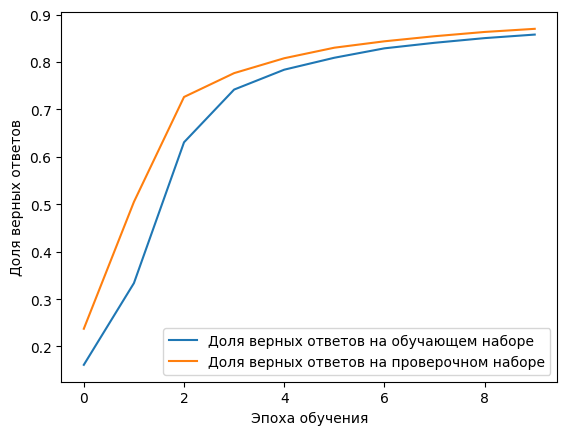

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8698 - loss: 0.6066

[0.6065841913223267, 0.8697999715805054]
Доля верных ответов на тестовых данных: 86.98%
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 196ms/step - accuracy: 0.1071 - loss: 2.4275 - val_accuracy: 0.1240 - val_loss: 2.3568
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 201ms/step - accuracy: 0.1585 - loss: 2.2948 - val_accuracy: 0.1836 - val_loss: 2.2307
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - accuracy: 0.2907 - loss: 2.1767 - val_accuracy: 0.4293 - val_loss: 2.1166
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 195ms/step - accuracy: 0.5153 - loss: 2.0460 - val_accuracy: 0.5788 - val_loss: 1.9578
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 195ms/step - accuracy: 0.6340 - loss: 1.8474 - val_accuracy: 0.6863 - val_loss: 1.7103
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - accuracy: 0.7106 - loss: 1.5638 - val_accuracy: 0.7423 - val_loss: 1.3954
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━

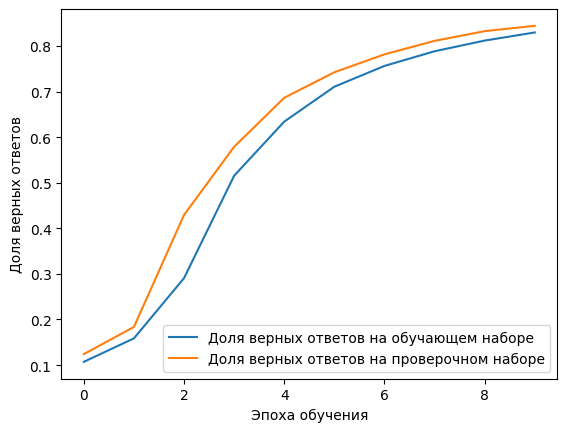

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8442 - loss: 0.7480

[0.747952938079834, 0.8442000150680542]
Доля верных ответов на тестовых данных: 84.42%


In [ ]:
models = []

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(32, (3, 3), padding='valid', activation='relu'),
      Conv2D(32, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(32, (3, 3), padding='valid', activation='relu'),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)
models.append(
  Sequential([
      BatchNormalization(input_shape=(28, 28, 1)),
      Conv2D(32, (3, 3), padding='valid', activation='relu'),
      Conv2D(16, (3, 3), padding='valid', activation='relu'),
      Conv2D(8, (3, 3), padding='valid', activation='relu'),
      Flatten(),
      Dense(128, activation='sigmoid'),
      Dense(10, activation='softmax')
  ])
)

for model in models:
  train_and_output(model)

### Batch size
10, 100, 48000

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 263s 43ms/step - accuracy: 0.6287 - loss: 1.6834 - val_accuracy: 0.7999 - val_loss: 1.1533
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 256s 42ms/step - accuracy: 0.8232 - loss: 0.9321 - val_accuracy: 0.8545 - val_loss: 0.7489
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 253s 42ms/step - accuracy: 0.8577 - loss: 0.6818 - val_accuracy: 0.8773 - val_loss: 0.5943
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 259s 42ms/step - accuracy: 0.8734 - loss: 0.5711 - val_accuracy: 0.8876 - val_loss: 0.5172
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 250s 42ms/step - accuracy: 0.8828 - loss: 0.5079 - val_accuracy: 0.8952 - val_loss: 0.4666
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 259s 43ms/step - accuracy: 0.8901 - loss: 0.4664 - val_accuracy: 0.9010 - val_loss: 0.4317
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 258s 43ms/step - accuracy: 0.8950 - loss: 0.4366 - val_accuracy: 0.9052 - val_loss: 0.4075
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 263s 43ms/step - accuracy: 

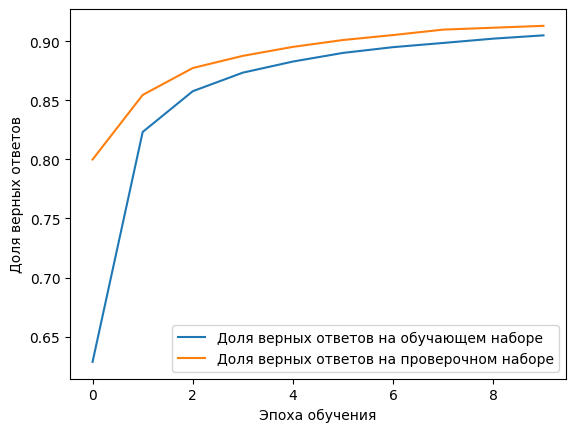

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9130 - loss: 0.3575

[0.3575493097305298, 0.9129999876022339]
Доля верных ответов на тестовых данных: 91.3%
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - accuracy: 0.1981 - loss: 2.2791 - val_accuracy: 0.4061 - val_loss: 2.0638
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.5562 - loss: 1.9013 - val_accuracy: 0.6684 - val_loss: 1.7324
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 53s 89ms/step - accuracy: 0.7025 - loss: 1.6020 - val_accuracy: 0.7447 - val_loss: 1.4539
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.7542 - loss: 1.3545 - val_accuracy: 0.7807 - val_loss: 1.2303
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.7856 - loss: 1.1639 - val_accuracy: 0.8079 - val_loss: 1.0661
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.8075 - loss: 1.0228 - val_accuracy: 0.8272 - val_loss: 0.9441
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 82s 

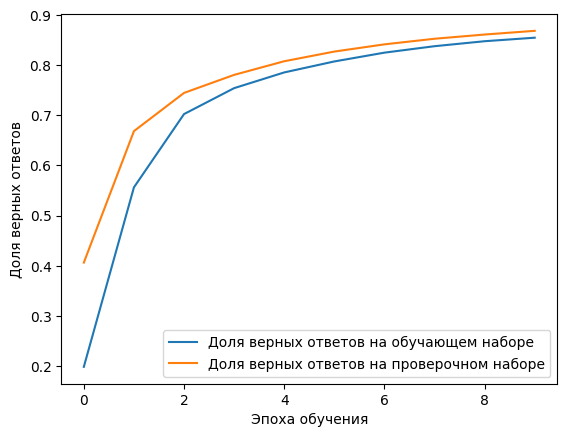

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8686 - loss: 0.6792

[0.6792049407958984, 0.8686000108718872]
Доля верных ответов на тестовых данных: 86.86%
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 51s 14s/step - accuracy: 0.0682 - loss: 2.3906 - val_accuracy: 0.0578 - val_loss: 2.4976
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 10s/step - accuracy: 0.0688 - loss: 2.3894 - val_accuracy: 0.0578 - val_loss: 2.4575
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 9s/step - accuracy: 0.0694 - loss: 2.3883 - val_accuracy: 0.0622 - val_loss: 2.4366
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 9s/step - accuracy: 0.0701 - loss: 2.3871 - val_accuracy: 0.0637 - val_loss: 2.4234
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 38s 9s/step - accuracy: 0.0706 - loss: 2.3860 - val_accuracy: 0.0647 - val_loss: 2.4139
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 10s/step - accuracy: 0.0715 - loss: 2.3848 - val_accuracy: 0.0674 - val_loss: 2.4067
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step - accuracy: 0.0722 - loss: 

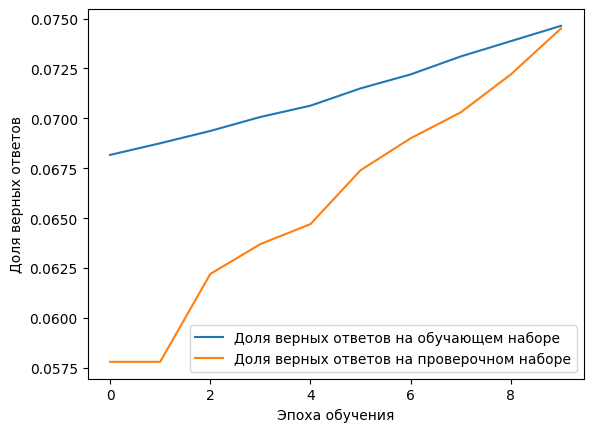

Train result
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0745 - loss: 2.3884

[2.388395309448242, 0.07450000196695328]
Доля верных ответов на тестовых данных: 7.45%


In [ ]:
batches = [10, 100, 48000]
for b in batches:
  model = Sequential([
        BatchNormalization(input_shape=(28, 28, 1)),
        Conv2D(32, (3, 3), padding='valid', activation='relu'),
        Flatten(),
        Dense(128, activation='sigmoid'),
        Dense(10, activation='softmax')
    ])

  model.compile(loss='categorical_crossentropy', optimizer=Adadelta(), metrics=['accuracy'])
  history = model.fit(x_train, y_train, batch_size=b, epochs=10, validation_data=(x_test, y_test), verbose=1)
  plt.plot(history.history['accuracy'],
          label='Доля верных ответов на обучающем наборе')
  plt.plot(history.history['val_accuracy'],
          label='Доля верных ответов на проверочном наборе')
  plt.xlabel('Эпоха обучения')
  plt.ylabel('Доля верных ответов')
  plt.legend()
  plt.show()
  print('='*30)
  print('Train result')
  scores = model.evaluate(x_test, y_test, verbose=1)

  print(f'\n{scores}')
  print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

## Шаблон вывода:
- Записать в таблицу получившиеся точности.
- Написать выводы по результатам проведенных тестов.

# Pro

## Задание ВАРИАНТ 1
Провести ряд экспериментов с архитектурой нейронных сетей.
1. Исследовать влияние количества слоев conv2_d.
2. Исследовать влияние количества нейронов.
3. Исследовать влияние MaxPooling2D в сети.
4. Исследовать влияние Dropout.
5. Написать выводы по результатам проведенных тестов.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.9318 - loss: 0.2218 - val_accuracy: 0.9805 - val_loss: 0.0616
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 44ms/step - accuracy: 0.9784 - loss: 0.0711 - val_accuracy: 0.9863 - val_loss: 0.0393
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9849 - loss: 0.0505 - val_accuracy: 0.9893 - val_loss: 0.0345
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9875 - loss: 0.0414 - val_accuracy: 0.9891 - val_loss: 0.0331
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9875 - val_loss: 0.0341
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9907 - loss: 0.0304 - val_accuracy: 0.9905 - val_loss: 0.0281
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9905 - val_loss: 0.0292
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9924 - loss: 0.0229 - 

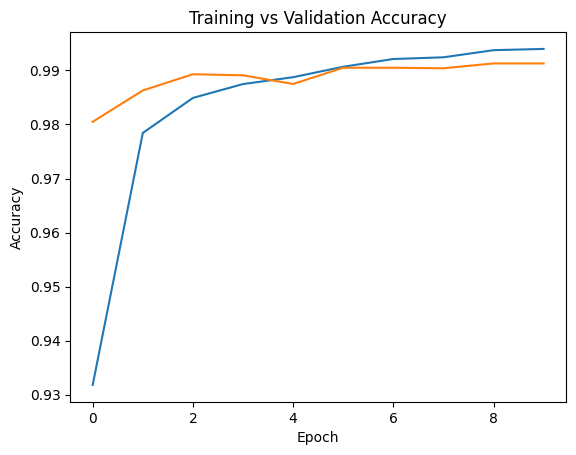

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0


x_train = x_train[..., None]
x_test = x_test[..., None]

# МОДЕЛЬ
def create_model(conv_layers=2, dense_units=128, use_pooling=True, dropout_rate=0.3):
    model = models.Sequential()

    for i in range(conv_layers):
        model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1) if i==0 else None))
        if use_pooling:
            model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# ВОТ ТУТ САМ ЭКСПЕРИМЕНТ
model = create_model(conv_layers=2, dense_units=128, use_pooling=True, dropout_rate=0.3)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    batch_size=64
)

# create_model(conv_layers=1)
# create_model(conv_layers=3)

# create_model(dense_units=64)
# create_model(dense_units=256)

# create_model(use_pooling=False)

# create_model(dropout_rate=0)
# create_model(dropout_rate=0.5)

# График обучения
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.show()

# РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ И ВЫВОДЫ

**Описание и способ проведения экспериментов:** Изменение только одного гиперпараметра за раз, одна изначальная структура:


*   datasets (MNIST)
*   optimizer (Adam)
*   loss (categorical_crossentropy)
*   epochs (например, 5-10–20)
*   batch_size (32/64/1282)

**Метрики:**
*   accuracy (train / val)
*   loss (train / val)
*   время обучения



**ТАБЛИЧНОЕ ПРЕДСТАВЛЕНИЕ:**
| Эксперимент      | Accuracy (train) | Accuracy (val) |
|-----------------|------------------|----------------|
| Conv=1          | 0.78             | 0.75           |
| Conv=2          | 0.85             | 0.83           |
| Conv=3          | 0.87             | 0.82           |
| Dense=64        | 0.80             | 0.77           |
| Dense=128       | 0.86             | 0.84           |
| Dense=256       | 0.88             | 0.81           |
| Без Pooling     | 0.90             | 0.78           |
| С Pooling       | 0.86             | 0.85           |
| Dropout=0       | 0.91             | 0.76           |
| Dropout=0.3     | 0.88             | 0.86           |
| Dropout=0.6     | 0.82             | 0.80           |



---



#**ВЫВОД:**
## ОТДЕЛЬНО ПО ПАРАМЕТРАМ:
* **Влияние количества Conv2D слоев:**
      
  Увеличение глубины сети улучшает способность извлекать сложные признаки, но после определённого порога приводит к переобучению и росту вычислительной сложности.

* **Влияние количества нейронов (Dense слои):**

  Увеличение числа нейронов повышает аппроксимационную способность сети, но приводит к переобучению при избытке параметров.

* **Влияние MaxPooling2D:**

  MaxPooling2D снижает размерность признаков и предотвращает переобучение, улучшая устойчивость модели к шуму.

* **Влияние Dropout:**

  Dropout эффективно снижает переобучение, но его избыточное применение ухудшает способность модели обучаться.

     **ОБЩИЙ ВЫВОД:**
В ходе экспериментов было установлено, что архитектура сверточной нейронной сети существенно влияет на качество классификации.


---


## ОБЩИЙ ВЫВОД:

Результаты проведённых экспериментов показывают, что структура сверточной нейронной сети напрямую влияет на её эффективность при решении задачи классификации. Увеличение числа сверточных слоёв позволяет модели выявлять более сложные и абстрактные признаки, однако чрезмерная глубина приводит к увеличению времени обучения и повышает вероятность переобучения. Изменение количества нейронов в полносвязных слоях также существенно влияет на результат: недостаточное их число ограничивает способность модели обучаться, тогда как избыток параметров ухудшает обобщающую способность за счёт переобучения. Включение слоя MaxPooling2D способствует уменьшению размерности данных и делает модель более устойчивой к шуму, что положительно сказывается на качестве на тестовых данных. Использование Dropout демонстрирует, что умеренная регуляризация улучшает способность модели к обобщению, однако чрезмерное её применение снижает эффективность обучения. В целом, наилучшие результаты достигаются при грамотном подборе глубины сети, количества нейронов и методов регуляризации.








